<img src="https://github.com/hernancontigiani/ceia_memorias_especializacion/raw/master/Figures/logoFIUBA.jpg" width="500" align="center">

## Procesamiento del Lenguaje Natural 1
### Carrera de Especialización en Inteligencia Artificial - FIUBA

## Desafío N° 3
### Modelo de lenguaje con tokenización por caracteres

### 1º Bimestre 2026

### Grupo

| Autores                     | E-mail                    | Nº SIU  |
|---------------------------- |---------------------------|---------|
| Juan E. Ramos Nervi         | jern10@gmail.com          | a1821   |


### Consigna
- Seleccionar un corpus de texto sobre el cual entrenar el modelo de lenguaje.
- Realizar el pre-procesamiento adecuado para tokenizar el corpus, estructurar el dataset y separar entre datos de entrenamiento y validación.
- Proponer arquitecturas de redes neuronales basadas en unidades recurrentes para implementar un modelo de lenguaje.
- Con el o los modelos que consideren adecuados, generar nuevas secuencias a partir de secuencias de contexto con las estrategias de greedy search y beam search determístico y estocástico. En este último caso observar el efecto de la temperatura en la generación de secuencias.


### Sugerencias
- Durante el entrenamiento, guiarse por el descenso de la perplejidad en los datos de validación para finalizar el entrenamiento. Para ello se provee un callback.
- Explorar utilizar SimpleRNN (celda de Elman), LSTM y GRU.
- rmsprop es el optimizador recomendado para la buena convergencia. No obstante se pueden explorar otros.


In [81]:
import sys
import tensorflow as tf

print("Python:", sys.version)
print("Executable:", sys.executable)
print("TensorFlow:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices('GPU'))

Python: 3.11.0 (main, Oct 24 2022, 18:26:48) [MSC v.1933 64 bit (AMD64)]
Executable: c:\Users\jeramosnervi\Documents\GitHub\CEIA-PNL\venv\Scripts\python.exe
TensorFlow: 2.21.0
GPUs: []


In [82]:
import sys, platform
print(sys.version)
print(sys.executable)
print(platform.architecture())

3.11.0 (main, Oct 24 2022, 18:26:48) [MSC v.1933 64 bit (AMD64)]
c:\Users\jeramosnervi\Documents\GitHub\CEIA-PNL\venv\Scripts\python.exe
('64bit', 'WindowsPE')


### 0. Librerías

In [83]:
# =========================
# Librerías generales
# =========================
import random
import io
import pickle
import re

import numpy as np
import matplotlib.pyplot as plt

# =========================
# Web scraping / descarga
# =========================
import requests
from bs4 import BeautifulSoup

# =========================
# Machine Learning
# =========================
from sklearn.model_selection import train_test_split

# =========================
# TensorFlow / Keras
# =========================
import tensorflow as tf
from tensorflow import keras

from tensorflow.keras.utils import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
from tensorflow.keras.callbacks import EarlyStopping

# =========================
# Configuración inicial
# =========================
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)
print("GPUs disponibles:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.21.0
GPUs disponibles: []


Utilizaremos como dataset la novela *Veinte mil leguas de viaje submarino* de Julio Verne, obtenida desde textos.info.

Para cumplir la consigna, en esta sección realizaremos:
- la carga del corpus,
- el pre-procesamiento básico,
- la tokenización por caracteres,
- la estructuración del dataset,
- y la separación entre entrenamiento y validación.

### 1. Dataset

In [84]:
# =========================
# Descarga y limpieza del corpus
# =========================

url = "https://www.textos.info/julio-verne/veinte-mil-leguas-de-viaje-submarino/ebook"

response = requests.get(url)
response.raise_for_status()

html = response.text
soup = BeautifulSoup(html, "html.parser")

# Extraer texto visible
article_text = soup.get_text(separator="\n")

# Pasar a minúsculas
article_text = article_text.lower()

# Recortar desde el inicio real del libro
start_marker = "el año 1866 quedó caracterizado"
start_idx = article_text.find(start_marker)

if start_idx != -1:
    article_text = article_text[start_idx:]
else:
    print("!!!!!!!!!-No se encontró el marcador de inicio")

# cortar basura del final
end_marker = "fin"
end_idx = article_text.rfind(end_marker)

if end_idx != -1:
    article_text = article_text[:end_idx]

# Limpieza básica
article_text = re.sub(r"\r", " ", article_text)
article_text = re.sub(r"\n+", "\n", article_text)
article_text = re.sub(r"[ \t]+", " ", article_text)

# Quitar espacios al inicio/fin
article_text = article_text.strip()

print("Cantidad de caracteres del corpus:", len(article_text))
print("\nPrimeros 1000 caracteres:\n")
print(article_text[:1000])

Cantidad de caracteres del corpus: 848550

Primeros 1000 caracteres:

el año 1866 quedó caracterizado por un extraño acontecimiento, por un 
 fenómeno inexplicable e inexplicado que nadie, sin duda, ha podido 
olvidar. sin hablar de los rumores que agitaban a las poblaciones de los 
 puertos y que sobreexcitaban a los habitantes del interior de los 
continentes, el misterioso fenómeno suscitó una particular emoción entre 
 los hombres del mar. negociantes, armadores, capitanes de barco, 
skippers y masters de europa y de américa, oficiales de la marina de 
guerra de todos los países y, tras ellos, los gobiernos de los 
diferentes estados de los dos continentes, manifestaron la mayor 
preocupación por el hecho.
desde hacía algún tiempo, en efecto, varios barcos se habían 
encontrado en sus derroteros con «una cosa enorme», con un objeto largo, 
 fusiforme, fosforescente en ocasiones, infinitamente más grande y más 
rápido que una ballena.
los hechos relativos a estas apariciones, consig

En `article_text` se encuentra el texto completo del libro ya cargado y preprocesado en forma básica.

In [85]:
# Segmentación del texto en secuencias (por párrafos / líneas)

segments = article_text.split("\n")

# limpieza básica
segments = [s.strip() for s in segments if len(s.strip()) > 0]

# filtro de ruido
segments = [s for s in segments if len(s) > 30]

print("Cantidad de segmentos:", len(segments))
print("\nEjemplos:")
for s in segments[:5]:
    print("-", s[:100])

import numpy as np

lengths = [len(s) for s in segments]

print("Promedio:", np.mean(lengths))
print("P90:", np.percentile(lengths, 90))
print("Max:", np.max(lengths))

Cantidad de segmentos: 11978

Ejemplos:
- el año 1866 quedó caracterizado por un extraño acontecimiento, por un
- fenómeno inexplicable e inexplicado que nadie, sin duda, ha podido
- olvidar. sin hablar de los rumores que agitaban a las poblaciones de los
- puertos y que sobreexcitaban a los habitantes del interior de los
- continentes, el misterioso fenómeno suscitó una particular emoción entre
Promedio: 67.00283853731841
P90: 72.0
Max: 128


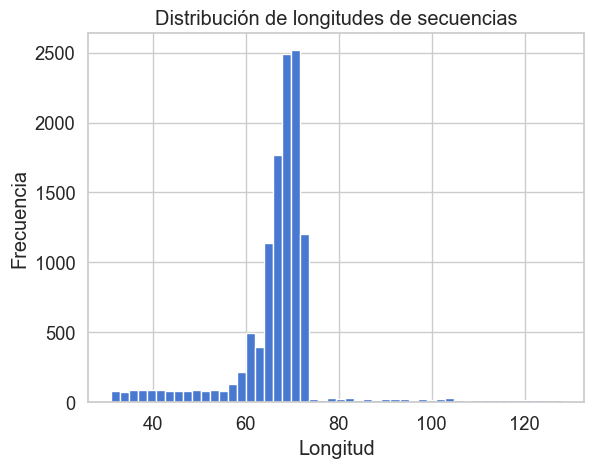

In [86]:
import matplotlib.pyplot as plt

plt.hist(lengths, bins=50)
plt.title("Distribución de longitudes de secuencias")
plt.xlabel("Longitud")
plt.ylabel("Frecuencia")
plt.show()

Elegir el tamaño del contexto

Se segmentó el corpus en secuencias textuales utilizando saltos de línea y se filtraron secuencias de longitud menor a 30 caracteres para reducir ruido. A partir del análisis de longitudes, se obtuvo un percentil 90 de aproximadamente 72 caracteres, por lo que se seleccionó un tamaño de contexto de 67 como compromiso entre capacidad de modelado y eficiencia computacional

In [87]:
# seleccionamos el tamaño de contexto
max_context_size = 67

In [88]:
# Construcción del vocabulario (caracteres únicos)
chars = sorted(list(set(article_text)))

# diccionarios
char2idx = {c: i for i, c in enumerate(chars)}
idx2char = {i: c for i, c in enumerate(chars)}

vocab_size = len(chars)

print("Tamaño del vocabulario:", vocab_size)
print("Ejemplo:", list(char2idx.items())[:10])

Tamaño del vocabulario: 66
Ejemplo: [('\n', 0), (' ', 1), ('!', 2), ('"', 3), ("'", 4), ('(', 5), (')', 6), (',', 7), ('-', 8), ('.', 9)]


### 2. Tokenización

Aplicamos el tokenizador de keras para convertir el texto en una secuencia de palabras.

In [89]:
# convertir cada segmento en secuencia de índices
tokenized_segments = [
    [char2idx[c] for c in segment if c in char2idx]
    for segment in segments
]

print("Ejemplo tokenizado:")
print(tokenized_segments[0][:50])
print("Cantidad de segmentos tokenizados:", len(tokenized_segments))
print("Longitud del primer segmento:", len(tokenized_segments[0]))
print("Primeros 20 tokens:", tokenized_segments[0][:20])

Ejemplo tokenizado:
[28, 35, 1, 24, 60, 38, 1, 12, 19, 17, 17, 1, 40, 44, 28, 27, 61, 1, 26, 24, 41, 24, 26, 43, 28, 41, 32, 49, 24, 27, 38, 1, 39, 38, 41, 1, 44, 37, 1, 28, 47, 43, 41, 24, 60, 38, 1, 24, 26, 38]
Cantidad de segmentos tokenizados: 11978
Longitud del primer segmento: 69
Primeros 20 tokens: [28, 35, 1, 24, 60, 38, 1, 12, 19, 17, 17, 1, 40, 44, 28, 27, 61, 1, 26, 24]


### 3. Generación de secuencias de n-gramas

Guardamos la secuencia de tokens en el texto. Esto debería ayudar al modelo a entender relaciones entre las palabras.

Cantidad de secuencias generadas: 790582
Ejemplo de secuencia: [28, 35]
Longitud del ejemplo: 2


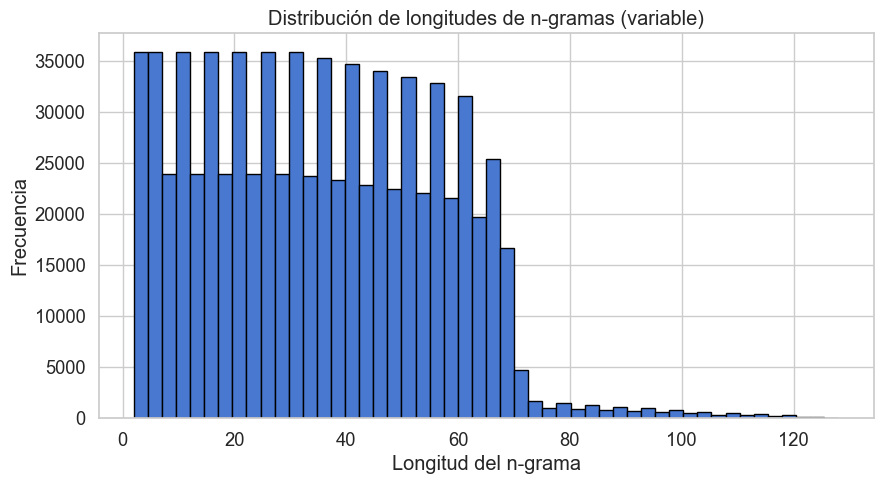

Promedio: 35.43354389550989
P90: 63.0
Max: 128


In [90]:
# ==========================================================
# Construcción de n-gramas de longitud variable
# ==========================================================

input_sequences = []
ngram_lengths = []

for segment in tokenized_segments:
    for i in range(1, len(segment)):
        n_gram_sequence = segment[:i+1]   # longitud variable
        input_sequences.append(n_gram_sequence)
        ngram_lengths.append(len(n_gram_sequence))

print("Cantidad de secuencias generadas:", len(input_sequences))
print("Ejemplo de secuencia:", input_sequences[0][:20])
print("Longitud del ejemplo:", len(input_sequences[0]))

# ==========================================================
# Histograma de longitudes
# ==========================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.hist(ngram_lengths, bins=50, edgecolor='black')

plt.title("Distribución de longitudes de n-gramas (variable)")
plt.xlabel("Longitud del n-grama")
plt.ylabel("Frecuencia")

plt.grid(True)
plt.show()

# ==========================================================
# Estadísticas útiles
# ==========================================================

import numpy as np

print("Promedio:", np.mean(ngram_lengths))
print("P90:", np.percentile(ngram_lengths, 90))
print("Max:", np.max(ngram_lengths))

A partir de cada segmento del corpus se generaron múltiples ejemplos de longitud variable, construidos de manera incremental. Esto permite realizar data augmentation, ya que de una misma secuencia original se obtienen múltiples pares entrada–salida considerando contextos crecientes

In [91]:
max_sequence_length = max(len(seq) for seq in input_sequences)


In [92]:
#Padding y data augmentation implicito
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np

# ==========================================================
# Padding de secuencias (todas al mismo tamaño)
# ==========================================================

# usamos max_context_size como longitud de entrada
# cada secuencia tendrá tamaño max_context_size + 1 (último es target)

max_len = max_context_size + 1

# padding a la izquierda
padded_sequences = pad_sequences(
    input_sequences,
    maxlen=max_len,
    padding='pre'
)

print("Shape padded:", padded_sequences.shape)
print("Ejemplo padded:", padded_sequences[0])

# ==========================================================
# Separación en input (X) y target (y)
# ==========================================================

X = padded_sequences[:, :-1]   # todo menos último
y = padded_sequences[:, -1]    # último token (target)

print("Shape X:", X.shape)
print("Shape y:", y.shape)

# ======================
# Ejemplo interpretado 
# ======================

ejemplo_idx = 0

input_text = "".join([idx2char[idx] for idx in X[ejemplo_idx] if idx != 0])
target_char = idx2char[y[ejemplo_idx]]

print("\nEjemplo interpretado:")
print("Input :", input_text)
print("Target:", target_char)

Shape padded: (790582, 68)
Ejemplo padded: [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 28 35]
Shape X: (790582, 67)
Shape y: (790582,)

Ejemplo interpretado:
Input : e
Target: l


### 4. Train/Validation/Test split

In [93]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.1,
    random_state=42,
    shuffle=True
)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

X_train: (711523, 67)
y_train: (711523,)
X_val: (79059, 67)
y_val: (79059,)


Pre-procesamiento y estructuración del dataset

Se realizó el pre-procesamiento del corpus mediante la descarga del texto, su parseo desde HTML, la conversión a minúsculas y una limpieza básica de saltos de línea y espacios redundantes. Luego se construyó un vocabulario de caracteres y se tokenizó el corpus a nivel carácter.

A partir del texto tokenizado se estructuró un dataset supervisado generando secuencias de longitud variable de forma incremental. Cada ejemplo de entrada corresponde a una secuencia de caracteres y su salida objetivo es el siguiente carácter, formulando el problema como un modelo de lenguaje many-to-one.

Dado que las secuencias poseen longitudes variables, se aplicó padding a la izquierda para unificar su tamaño. Finalmente, el dataset fue dividido en conjuntos de entrenamiento y validación, reservando un 10% para validación.

## Propoestas de modelos
## Arquitecturas de modelos de lenguaje basadas en RNN

Para implementar el modelo de lenguaje se proponen arquitecturas basadas en redes neuronales recurrentes (RNN), las cuales son adecuadas para modelar dependencias secuenciales en datos de texto.

En particular, se consideran las siguientes variantes:

* **SimpleRNN (celda de Elman):** arquitectura recurrente básica que permite modelar dependencias temporales simples.
* **GRU (Gated Recurrent Unit):** introduce mecanismos de compuertas que permiten capturar dependencias de mayor alcance de manera eficiente.
* **LSTM (Long Short-Term Memory):** arquitectura más compleja que incorpora memoria explícita y mecanismos de control del flujo de información.

En todos los casos, se utiliza una capa de **Embedding** para representar los caracteres en un espacio vectorial denso, evitando el uso de codificación one-hot.

La arquitectura general es:

**Embedding → Capa recurrente → Capa densa (softmax)**

Dado que el problema se formuló como *many-to-one*, el modelo predice el siguiente carácter a partir de una secuencia de entrada.


In [94]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, SimpleRNN, Dense

embedding_dim = 300

model_rnn = Sequential([
    Input(shape=(X_train.shape[1],)),
    
    Embedding(
        input_dim=vocab_size,            
        output_dim=embedding_dim,
        input_length=X_train.shape[1]
    ),
    
    SimpleRNN(150),
    
    Dense(vocab_size, activation="softmax")
])

model_rnn.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="rmsprop",
    metrics=["accuracy"]
)

model_rnn.summary()

c:\Users\jeramosnervi\Documents\GitHub\CEIA-PNL\venv\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 67, 300)        │        19,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 150)            │        67,650 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 66)             │         9,966 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 97,416 (380.53 KB)

 Trainable params: 97,416 (380.53 KB)

 Non-trainable params: 0 (0.00 B)

In [95]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, GRU, Dense

embedding_dim = 300

model_gru = Sequential([
    Input(shape=(X_train.shape[1],)),   
    
    Embedding(
        input_dim=vocab_size,           
        output_dim=embedding_dim,
        input_length=X_train.shape[1]
    ),
    
    GRU(150),
    
    Dense(vocab_size, activation="softmax")
])

model_gru.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="rmsprop",
    metrics=["accuracy"]
)

model_gru.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 67, 300)        │        19,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 150)            │       203,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 66)             │         9,966 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 233,166 (910.80 KB)

 Trainable params: 233,166 (910.80 KB)

 Non-trainable params: 0 (0.00 B)

In [96]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense

embedding_dim = 300

model_lstm = Sequential([
    Input(shape=(X_train.shape[1],)),   
    
    Embedding(
        input_dim=vocab_size,           
        output_dim=embedding_dim,
        input_length=X_train.shape[1]
    ),
    
    LSTM(150),
    
    Dense(vocab_size, activation="softmax")
])

model_lstm.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="rmsprop",
    metrics=["accuracy"]
)

model_lstm.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 67, 300)        │        19,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 150)            │       270,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 66)             │         9,966 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 300,366 (1.15 MB)

 Trainable params: 300,366 (1.15 MB)

 Non-trainable params: 0 (0.00 B)

#### 5.2. Entrenamiento

In [97]:
import numpy as np
from tensorflow import keras

class PplCallback(keras.callbacks.Callback):
    """
    Callback para calcular perplexity al final de cada epoch
    sobre el conjunto de validación en un esquema many-to-one.
    """

    def __init__(self, X_val, y_val, history_ppl):
        super().__init__()
        self.X_val = X_val
        self.y_val = y_val
        self.history_ppl = history_ppl

    def on_epoch_end(self, epoch, logs=None):
        # predicciones
        predictions = self.model.predict(self.X_val, verbose=0)

        # probabilidad del target correcto
        epsilon = 1e-8
        probs = predictions[np.arange(len(self.y_val)), self.y_val]
        probs = np.clip(probs, epsilon, 1.0)   # ✔ evita log(0)

        # perplexity
        ppl = np.exp(-np.mean(np.log(probs)))
        self.history_ppl.append(float(ppl))

        print(f"\nEpoch {epoch+1} - Perplexity: {ppl:.3f}")

In [98]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, SimpleRNN, GRU, LSTM, Dense

embedding_dim = 32

def build_model(model_name):
    model = Sequential()
    
    model.add(Input(shape=(X_train.shape[1],)))  
    
    model.add(Embedding(
        input_dim=vocab_size,                   
        output_dim=embedding_dim,
        input_length=X_train.shape[1]           
    ))

    if model_name == "rnn":
        model.add(SimpleRNN(64))
    elif model_name == "gru":
        model.add(GRU(64))
    elif model_name == "lstm":
        model.add(LSTM(64))
    else:
        raise ValueError("Modelo no reconocido")

    model.add(Dense(vocab_size, activation="softmax"))

    model.compile(
        loss="sparse_categorical_crossentropy",
        optimizer="rmsprop",
        metrics=["accuracy"]
    )

    return model

In [99]:
import gc
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import backend as K

results = {}

model_types = ["rnn", "gru", "lstm"]

for model_name in model_types:
    print(f"\n{'='*80}")
    print(f"Entrenando modelo: {model_name.upper()}")
    print(f"{'='*80}\n")

    # recreamos el modelo desde cero
    model = build_model(model_name)

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True
    )

    history_ppl = []
    ppl_callback = PplCallback(X_val, y_val, history_ppl)

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=30,
        batch_size=128,
        callbacks=[early_stop, ppl_callback],
        verbose=1
    )

    # guardar modelo
    filename = f"{model_name}_model.keras"
    model.save(filename)

    # guardar resultados
    results[model_name] = {
        "history": history.history,
        "perplexity": history_ppl,
        "model_file": filename
    }

    # guardar CSV
    history_df = pd.DataFrame(history.history)
    history_df["perplexity"] = history_ppl
    csv_name = f"{model_name}_history.csv"
    history_df.to_csv(csv_name, index=False)

    print(f"Modelo guardado en: {filename}")
    print(f"Historial guardado en: {csv_name}")

    # ===============
    # PLOT ACCURACY 
    # ===============
    sns.set(style="whitegrid", palette="muted", font_scale=1.2)

    epoch_count = range(1, len(history.history["accuracy"]) + 1)

    plt.figure(figsize=(10, 6))
    sns.lineplot(x=epoch_count, y=history.history["accuracy"], label="Train", linewidth=2)
    
    if "val_accuracy" in history.history:
        sns.lineplot(x=epoch_count, y=history.history["val_accuracy"], label="Validation", linewidth=2)

    plt.title(f"Accuracy by epochs - {model_name.upper()}", fontsize=16)
    plt.xlabel("Epoch", fontsize=14)
    plt.ylabel("Accuracy", fontsize=14)
    plt.legend(loc="lower right", fontsize=12)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # =========================
    # PLOT PERPLEXITY
    # =========================
    plt.figure(figsize=(10, 6))
    sns.lineplot(
        x=range(1, len(history_ppl) + 1),
        y=history_ppl,
        label="Validation Perplexity",
        linewidth=2
    )
    plt.title(f"Perplexity by epochs - {model_name.upper()}", fontsize=16)
    plt.xlabel("Epoch", fontsize=14)
    plt.ylabel("Perplexity", fontsize=14)
    plt.legend(fontsize=12)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # =========================
    # LIMPIEZA
    # =========================
    del model
    gc.collect()
    K.clear_session()


Entrenando modelo: RNN

Epoch 1/30
3358/5559 ━━━━━━━━━━━━━━━━━━━━ 29s 13ms/step - accuracy: 0.2914 - loss: 2.4187

KeyboardInterrupt: 


## **OBSERVACIONES:**

* Los tres modelos mejoran progresivamente durante el entrenamiento, evidenciando convergencia.

* **SimpleRNN** presenta el peor desempeño, con menor accuracy y mayor perplexity, además de una leve gap entre training y validation.

* **GRU** mejora significativamente la performance, mostrando buena generalización y estabilidad entre ambas curvas.

* **LSTM** alcanza el mejor resultado global (mayor accuracy y menor perplexity), con curvas de training y validation muy próximas.

* En conjunto, **GRU y LSTM superan claramente a SimpleRNN**, siendo LSTM el modelo más robusto.

*Por lo tanto, se decide continuar con el modelo **LSTM**.*



### 6. Modelo LSTM #2

#### 6.1. Arquitectura

Agregamos capas de Dropout para ver si logramos que el modelo generalicé mejor.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, LSTM, Dropout, Dense

embedding_dim = 32
lstm_units = 64
fc_units = 32
dropout_rate = 0.20

model_lstm_dropout = Sequential([
    Input(shape=(X_train.shape[1],)),   
    
    Embedding(
        input_dim=vocab_size,         
        output_dim=embedding_dim,
        input_length=X_train.shape[1]   
    ),
    
    LSTM(lstm_units, return_sequences=True),
    Dropout(dropout_rate),
    
    LSTM(lstm_units),
    Dropout(dropout_rate),
    
    Dense(fc_units, activation='relu'),
    
    Dense(vocab_size, activation='softmax')
])

model_lstm_dropout.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="rmsprop",
    metrics=["accuracy"]
)

model_lstm_dropout.summary()

c:\Users\jeramosnervi\Documents\GitHub\CEIA-PNL\venv\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 63, 32)         │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 63, 64)         │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 63, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 66)             │         2,178 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 64,226 (250.88 KB)

 Trainable params: 64,226 (250.88 KB)

 Non-trainable params: 0 (0.00 B)

#### 6.2. Entrenamiento


Entrenando modelo: LSTM_DROPOUT-V2

Epoch 1/30
5559/5559 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.4016 - loss: 1.9726
Epoch 1 - Perplexity: 6.004
5559/5559 ━━━━━━━━━━━━━━━━━━━━ 453s 81ms/step - accuracy: 0.4110 - loss: 1.9394 - val_accuracy: 0.4542 - val_loss: 1.7924
Epoch 2/30
5559/5559 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.4302 - loss: 1.8698
Epoch 2 - Perplexity: 5.574
5559/5559 ━━━━━━━━━━━━━━━━━━━━ 459s 83ms/step - accuracy: 0.4352 - loss: 1.8548 - val_accuracy: 0.4786 - val_loss: 1.7181
Epoch 3/30
5559/5559 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.4477 - loss: 1.8132
Epoch 3 - Perplexity: 5.317
5559/5559 ━━━━━━━━━━━━━━━━━━━━ 457s 82ms/step - accuracy: 0.4509 - loss: 1.8034 - val_accuracy: 0.4915 - val_loss: 1.6709
Epoch 4/30
5559/5559 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.4587 - loss: 1.7753
Epoch 4 - Perplexity: 5.133
5559/5559 ━━━━━━━━━━━━━━━━━━━━ 501s 82ms/step - accuracy: 0.4616 - loss: 1.7670 - val_accuracy: 0.5014 - val_loss: 1.6356
Epoch 5

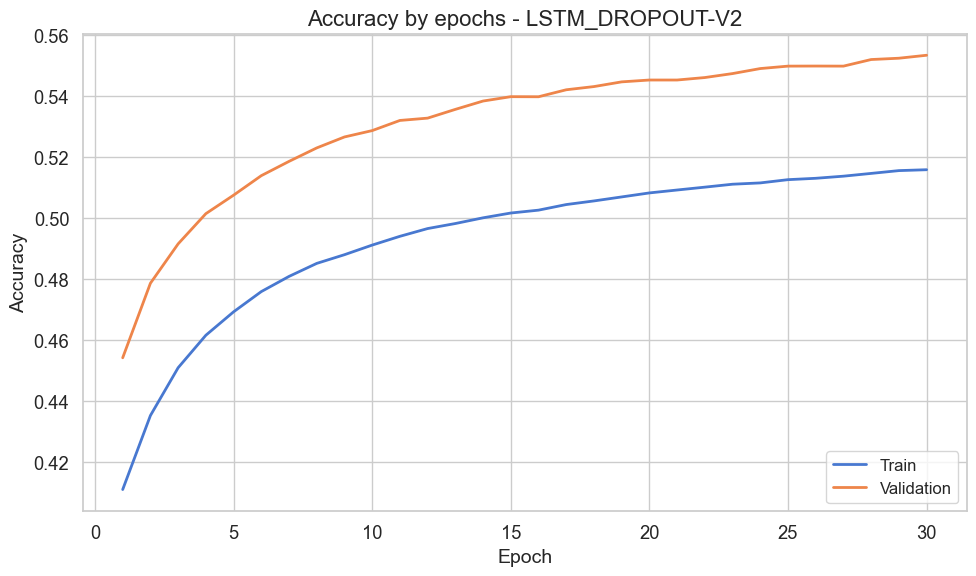

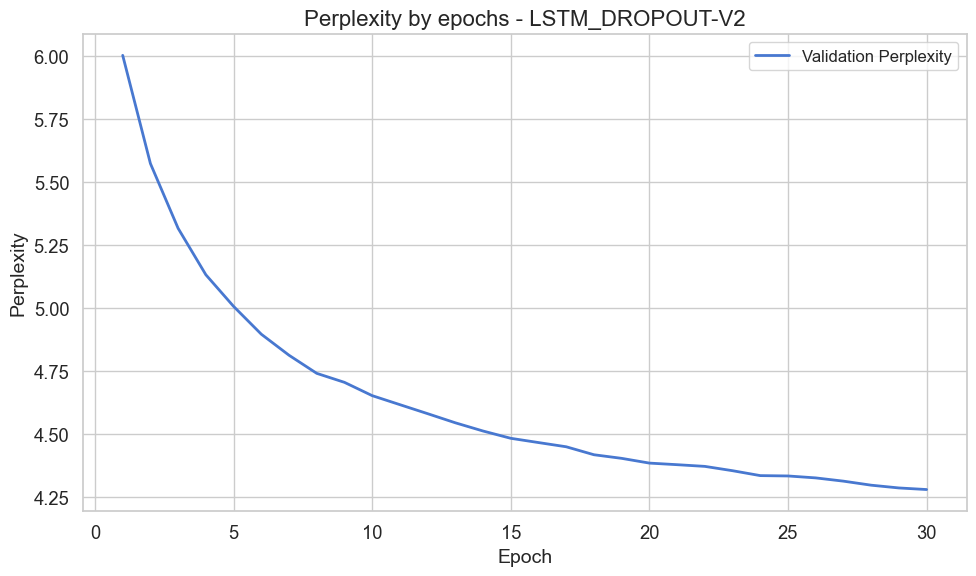

In [ ]:
import os
import gc
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.models import load_model
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import backend as K

results = {}

model_name = "lstm_dropout-v2"
filename = f"{model_name}_model.keras"
csv_name = f"{model_name}_history.csv"

print(f"\n{'='*80}")
print(f"Entrenando modelo: {model_name.upper()}")
print(f"{'='*80}\n")

# =============
# COMPILACIÓN 
# =============

optimizer = Adam(learning_rate=0.001)

model_lstm_dropout.compile(
    loss=SparseCategoricalCrossentropy(),
    optimizer=optimizer,
    metrics=["accuracy"]
)

# =============
# CALLBACKS
# =============

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True
)

history_ppl = []
ppl_callback = PplCallback(X_val, y_val, history_ppl)

# ==========================================================
# ENTRENAMIENTO O CARGA
# ==========================================================

if os.path.exists(filename):
    print(f"Se encontró un modelo guardado: {filename}")
    print("Cargando modelo existente...\n")
    
    model_lstm_dropout = load_model(filename)
    
else:
    history = model_lstm_dropout.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=30,
        batch_size=128,
        callbacks=[early_stop, ppl_callback],
        verbose=1
    )

    # ==========================================================
    # GUARDADO
    # ==========================================================

    model_lstm_dropout.save(filename)

    results[model_name] = {
        "history": history.history,
        "perplexity": history_ppl,
        "model_file": filename
    }

    # CSV
    history_df = pd.DataFrame(history.history)
    history_df["perplexity"] = history_ppl
    history_df.to_csv(csv_name, index=False)

    print(f"Modelo guardado en: {filename}")
    print(f"Historial guardado en: {csv_name}")

    # ==========================================================
    # PLOT ACCURACY
    # ==========================================================

    sns.set(style="whitegrid", palette="muted", font_scale=1.2)

    epoch_count = range(1, len(history.history["accuracy"]) + 1)

    plt.figure(figsize=(10, 6))
    sns.lineplot(x=epoch_count, y=history.history["accuracy"], label="Train", linewidth=2)
    
    if "val_accuracy" in history.history:
        sns.lineplot(x=epoch_count, y=history.history["val_accuracy"], label="Validation", linewidth=2)

    plt.title(f"Accuracy by epochs - {model_name.upper()}", fontsize=16)
    plt.xlabel("Epoch", fontsize=14)
    plt.ylabel("Accuracy", fontsize=14)
    plt.legend(loc="lower right", fontsize=12)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # ==========================================================
    # PLOT PERPLEXITY
    # ==========================================================

    plt.figure(figsize=(10, 6))
    sns.lineplot(
        x=range(1, len(history_ppl) + 1),
        y=history_ppl,
        label="Validation Perplexity",
        linewidth=2
    )

    plt.title(f"Perplexity by epochs - {model_name.upper()}", fontsize=16)
    plt.xlabel("Epoch", fontsize=14)
    plt.ylabel("Perplexity", fontsize=14)
    plt.legend(fontsize=12)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# ==========================================================
# LIMPIEZA
# ==========================================================

gc.collect()
K.clear_session()

In [ ]:
import os

# Crear carpeta si no existe
os.makedirs("models", exist_ok=True)

# Guardar modelos 
if "model_lstm" in globals():
    model_lstm.save("models/lstm_model.keras")
    print("- models/lstm_model.keras guardado")

if "model_lstm_dropout" in globals():
    model_lstm_dropout.save("models/lstm_dropout_model.keras")
    print("- models/lstm_dropout_model.keras guardado")

print("\nModelos guardados correctamente")

- models/lstm_model.keras guardado
- models/lstm_dropout_model.keras guardado

Modelos guardados correctamente


El modelo **LSTM + Dropout** presenta una mejor generalización que el LSTM simple, evidenciada por un mayor accuracy en validation y menor perplexity.

Además, el uso de dropout reduce el sobreajuste, logrando una brecha más controlada entre training y validation y un aprendizaje más robusto.

### 7. Modelo #3 BiLSTM

#### 7.1 Arquitectura

Usamos la misma arquitectura que el caso anterior, pero aplicamos Bidirectional en las capas LSTM para entender tanto hacia adelante como hacia atrás.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, LSTM, Bidirectional, Dropout, Dense

embedding_dim = 32
lstm_units = 64
fc_units = 32
dropout_rate = 0.20

model_bilstm = Sequential([
    Input(shape=(X_train.shape[1],)),   
    
    Embedding(
        input_dim=vocab_size,           
        output_dim=embedding_dim,
        input_length=X_train.shape[1]
    ),
    
    Bidirectional(LSTM(lstm_units, return_sequences=True)),
    Dropout(dropout_rate),
    
    LSTM(lstm_units),
    Dropout(dropout_rate),
    
    Dense(fc_units, activation='relu'),
    Dense(vocab_size, activation='softmax')
])

model_bilstm.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="rmsprop",
    metrics=["accuracy"]
)

model_bilstm.summary()

c:\Users\jeramosnervi\Documents\GitHub\CEIA-PNL\venv\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 63, 32)         │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 63, 128)        │        49,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 63, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 66)             │         2,178 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 105,442 (411.88 KB)

 Trainable params: 105,442 (411.88 KB)

 Non-trainable params: 0 (0.00 B)

#### 7.2 Entrenamiento


Entrenando modelo: BILSTM-V2

Epoch 1/30
5559/5559 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.4140 - loss: 1.9457
Epoch 1 - Perplexity: 5.769
5559/5559 ━━━━━━━━━━━━━━━━━━━━ 586s 105ms/step - accuracy: 0.4249 - loss: 1.9014 - val_accuracy: 0.4663 - val_loss: 1.7526
Epoch 2/30
5559/5559 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.4483 - loss: 1.8179
Epoch 2 - Perplexity: 5.295
5559/5559 ━━━━━━━━━━━━━━━━━━━━ 573s 103ms/step - accuracy: 0.4532 - loss: 1.8012 - val_accuracy: 0.4943 - val_loss: 1.6668
Epoch 3/30
5559/5559 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.4668 - loss: 1.7520
Epoch 3 - Perplexity: 5.035
5559/5559 ━━━━━━━━━━━━━━━━━━━━ 629s 113ms/step - accuracy: 0.4707 - loss: 1.7399 - val_accuracy: 0.5068 - val_loss: 1.6165
Epoch 4/30
5559/5559 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.4807 - loss: 1.7065
Epoch 4 - Perplexity: 4.816
5559/5559 ━━━━━━━━━━━━━━━━━━━━ 519s 93ms/step - accuracy: 0.4832 - loss: 1.6974 - val_accuracy: 0.5188 - val_loss: 1.5720
Epoch 5/30

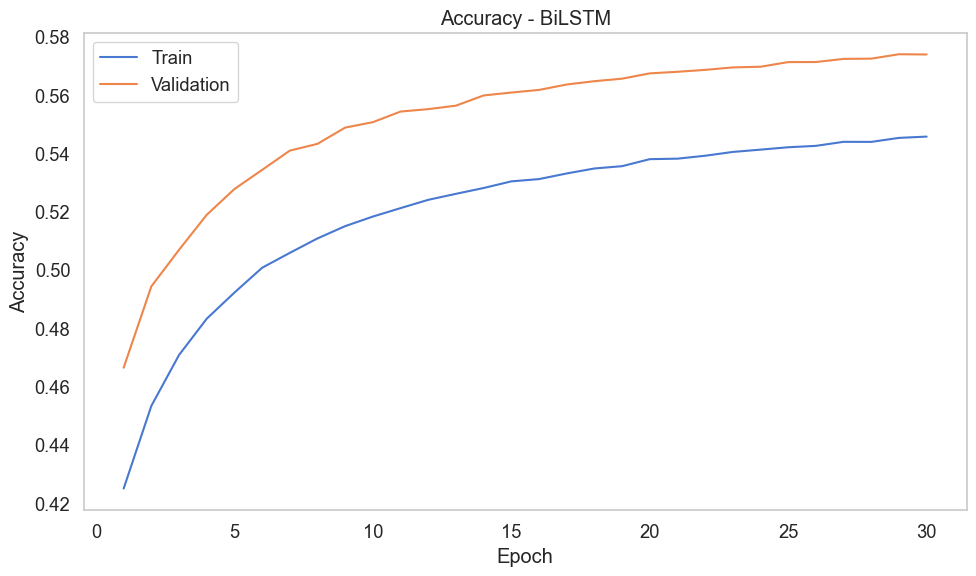

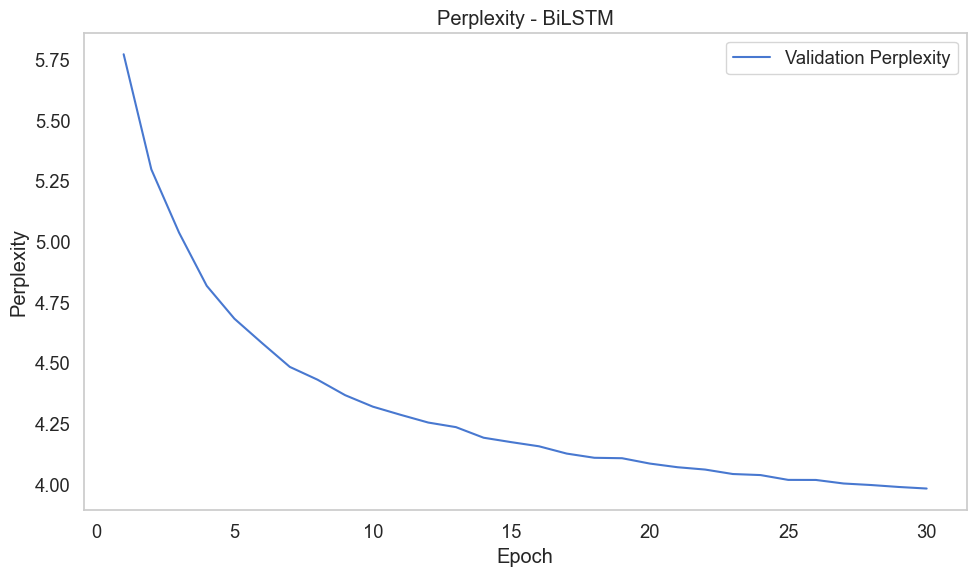

In [ ]:
import os
import gc
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.models import load_model
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import backend as K

results = {}

model_name = "bilstm-v2"
filename = f"{model_name}_model.keras"
csv_name = f"{model_name}_history.csv"

print(f"\n{'='*80}")
print(f"Entrenando modelo: {model_name.upper()}")
print(f"{'='*80}\n")

# ==========================================================
# CALLBACKS
# ==========================================================

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True
)

history_ppl = []
ppl_callback = PplCallback(X_val, y_val, history_ppl)

# ==========================================================
# ENTRENAMIENTO O CARGA
# ==========================================================

if os.path.exists(filename):
    print(f"Modelo encontrado: {filename}")
    print("Cargando modelo...\n")

    model_bilstm = load_model(filename)

    # ⚠️ importante: recompilar después de cargar
    model_bilstm.compile(
        loss=SparseCategoricalCrossentropy(),
        optimizer=Adam(learning_rate=0.001),
        metrics=["accuracy"]
    )

else:
    # compilación antes de entrenar
    model_bilstm.compile(
        loss=SparseCategoricalCrossentropy(),
        optimizer=Adam(learning_rate=0.001),
        metrics=["accuracy"]
    )

    history = model_bilstm.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=30,
        batch_size=128,
        callbacks=[early_stop, ppl_callback],
        verbose=1
    )

    # ==========================================================
    # GUARDADO
    # ==========================================================

    model_bilstm.save(filename)

    history_df = pd.DataFrame(history.history)
    history_df["perplexity"] = history_ppl
    history_df.to_csv(csv_name, index=False)

    print(f"Modelo guardado en: {filename}")
    print(f"Historial guardado en: {csv_name}")

    # ==========================================================
    # PLOTS
    # ==========================================================

    sns.set(style="whitegrid", palette="muted", font_scale=1.2)

    epoch_count = range(1, len(history.history["accuracy"]) + 1)

    # Accuracy
    plt.figure(figsize=(10, 6))
    sns.lineplot(x=epoch_count, y=history.history["accuracy"], label="Train")
    
    if "val_accuracy" in history.history:
        sns.lineplot(x=epoch_count, y=history.history["val_accuracy"], label="Validation")

    plt.title("Accuracy - BiLSTM")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()

    # Perplexity
    plt.figure(figsize=(10, 6))
    sns.lineplot(
        x=range(1, len(history_ppl)+1),
        y=history_ppl,
        label="Validation Perplexity"
    )
    plt.title("Perplexity - BiLSTM")
    plt.xlabel("Epoch")
    plt.ylabel("Perplexity")
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()

# ==========================================================
# LIMPIEZA
# ==========================================================

gc.collect()
K.clear_session()

In [ ]:
import os

# Crear carpeta si no existe
os.makedirs("models", exist_ok=True)

filepath = os.path.join("models", "bilstm_model.keras")

# Guardar solo si el modelo existe
if "model_bilstm" in globals():
    model_bilstm.save(filepath)
    print(f"Modelo BiLSTM guardado en: {filepath}")
else:
    print("model_bilstm no está definido. Entrená o cargá el modelo antes de guardar.")

El modelo **BiLSTM** supera al **LSTM + Dropout**, alcanzando mayor accuracy y menor perplexity, lo que indica una mejor capacidad para capturar dependencias contextuales.

Esto se debe a que el procesamiento bidireccional permite aprovechar información pasada y futura, logrando representaciones más ricas del lenguaje.

### 9. Predicción próxima palabra

Con el o los modelos que consideren adecuados, generar nuevas secuencias a partir de secuencias de contexto con las estrategias de greedy search y beam search determístico y estocástico. En este último caso observar el efecto de la temperatura en la generación de secuencias.

In [114]:
import numpy as np

def predict_next_word_char_level(input_text, model, char2idx, idx2char, max_context_size, max_word_len=20):
    output_word = ""

    current_text = input_text

    for _ in range(max_word_len):
        encoded = encode_text(current_text, char2idx, max_context_size)
        preds = model.predict(encoded, verbose=0)[0]

        # evitar padding
        preds[0] = 0

        next_index = int(np.argmax(preds))
        next_char = idx2char[next_index]

        # si todavía no arrancó la palabra, ignorar espacios iniciales
        if output_word == "" and next_char in [" ", "\n", "\t"]:
            current_text += next_char
            continue

        # cortar al llegar a separador
        if next_char in [" ", "\n", "\t", ".", ",", ";", ":", "!", "?", "—", "-"]:
            break

        output_word += next_char
        current_text += next_char

    return output_word if output_word != "" else None

In [115]:
inputs = ["el capitán", "el mar", "aquella"]

best_model = model_bilstm   # o model_lstm_dropout

for input_text in inputs:
    print(f"Input text: {input_text}")
    next_word = predict_next_word_char_level(
        input_text,
        best_model,
        char2idx,
        idx2char,
        max_context_size
    )
    print(f"Next word: {next_word}")
    print("")

Input text: el capitán
Next word: nemo

Input text: el mar
Next word: de

Input text: aquella
Next word: de



### 10. Generación de texto (Greedy)



In [116]:
def predict_next_char(input_text, model, char2idx, idx2char, max_context_size):
    encoded = encode_text(input_text, char2idx, max_context_size)
    predicted = model.predict(encoded, verbose=0)[0]

    # evitar seleccionar padding
    predicted[0] = 0

    predicted_index = int(np.argmax(predicted))
    predicted_char = idx2char[predicted_index]

    return predicted_char


def generate_seq_greedy(model, seed_text, n_chars, char2idx, idx2char, max_context_size):
    output_text = seed_text

    for _ in range(n_chars):
        next_char = predict_next_char(
            output_text,
            model,
            char2idx,
            idx2char,
            max_context_size
        )

        output_text += next_char

    return output_text

In [117]:
seed_texts = [
    "el capitán nemo",
    "el mar era",
    "aquella noche"
]

best_model = model_bilstm

for seed_text in seed_texts:
    print("="*80)
    print("Seed:", seed_text)
    print("="*80)

    print(generate_seq_greedy(
        best_model,
        seed_text,
        n_chars=150,
        char2idx=char2idx,
        idx2char=idx2char,
        max_context_size=max_context_size
    ))

    print()

Seed: el capitán nemo
el capitán nemo se había había descendió el capitán nemo se había había descendió el capitán nemo se había había descendió el capitán nemo se había había descendió e

Seed: el mar era
el mar era el capitán nemo se había había descendió el capitán nemo se había había descendió el capitán nemo se había había descendió el capitán nemo se había h

Seed: aquella noche
aquella noche de la corriente de la corriente de la corriente de la corriente de la corriente de la corriente de la corriente de la corriente de la corriente de la



La estrategia *greedy* genera secuencias coherentes a corto plazo, pero tiende a caer en repeticiones y baja diversidad al seleccionar siempre el carácter más probable.


### 11.beam search determístico 

In [118]:
def beam_search_deterministic(model, seed_text, n_chars, beam_width, char2idx, idx2char, max_context_size):
    beams = [(seed_text, 0.0)]

    for _ in range(n_chars):
        candidates = []

        for seq, score in beams:
            encoded = encode_text(seq, char2idx, max_context_size)
            preds = model.predict(encoded, verbose=0)[0]

            # evitar padding
            preds[0] = 0

            top_indices = np.argsort(preds)[-beam_width:][::-1]

            for idx in top_indices:
                next_char = idx2char[idx]
                new_seq = seq + next_char
                new_score = score + np.log(preds[idx] + 1e-10)

                candidates.append((new_seq, new_score))

        beams = sorted(candidates, key=lambda x: x[1], reverse=True)[:beam_width]

    return beams[0][0], beams

In [119]:
best_model = model_bilstm

seed_text = "el capitán nemo"

generated_beam_det, beams_det = beam_search_deterministic(
    best_model,
    seed_text,
    n_chars=150,
    beam_width=3,
    char2idx=char2idx,
    idx2char=idx2char,
    max_context_size=max_context_size
)

print(generated_beam_det)

el capitán nemo, el capitán nemo el capitán nemo, el capitán nemo el capitán nemo, el capitán nemo el capitán nemo, el capitán nemo el capitán nemo, el capitán nemo 


In [120]:
for i, (seq, score) in enumerate(beams_det):
    print("="*80)
    print(f"Beam {i+1} | score: {score:.4f}")
    print("="*80)
    print(seq)
    print()

Beam 1 | score: -61.7018
el capitán nemo, el capitán nemo el capitán nemo, el capitán nemo el capitán nemo, el capitán nemo el capitán nemo, el capitán nemo el capitán nemo, el capitán nemo 

Beam 2 | score: -63.2522
el capitán nemo, el capitán nemo el capitán nemo, el capitán nemo el capitán nemo, el capitán nemo el capitán nemo, el capitán nemo el capitán nemo, el capitán nemo,

Beam 3 | score: -63.6748
el capitán nemo, el capitán nemo el capitán nemo, el capitán nemo el capitán nemo, el capitán nemo el capitán nemo, el capitán nemo el capitán nemo, el capitán nemo.



El beam search determinístico mejora el control de la probabilidad acumulada, pero en este caso refuerza patrones muy probables del modelo y cae en repeticiones de “el capitán nemo”, mostrando baja diversidad.

### 12. Beam search estocastico

In [121]:
def beam_search_stochastic(model, seed_text, n_chars, beam_width, char2idx, idx2char, max_context_size, temperature=1.0):
    beams = [(seed_text, 0.0)]

    for _ in range(n_chars):
        candidates = []

        for seq, score in beams:
            encoded = encode_text(seq, char2idx, max_context_size)
            preds = model.predict(encoded, verbose=0)[0]

            preds = np.asarray(preds).astype("float64")

            # evitar padding
            preds[0] = 0

            preds = np.log(preds + 1e-8) / temperature
            exp_preds = np.exp(preds)
            probs = exp_preds / np.sum(exp_preds)

            sampled_indices = np.random.choice(
                np.arange(len(probs)),
                size=beam_width,
                replace=False,
                p=probs
            )

            for idx in sampled_indices:
                next_char = idx2char[idx]
                new_seq = seq + next_char
                new_score = score + np.log(probs[idx] + 1e-10)

                candidates.append((new_seq, new_score))

        beams = sorted(candidates, key=lambda x: x[1], reverse=True)[:beam_width]

    return beams[0][0], beams

In [122]:
best_model = model_bilstm

seed_text = "el capitán nemo"
temperatures = [0.5, 1.0, 1.5]

for temp in temperatures:
    print("="*80)
    print(f"Beam search estocástico - temperatura = {temp}")
    print("="*80)

    generated_beam_stoch, beams_stoch = beam_search_stochastic(
        best_model,
        seed_text,
        n_chars=150,
        beam_width=3,
        char2idx=char2idx,
        idx2char=idx2char,
        max_context_size=max_context_size,
        temperature=temp
    )

    print(generated_beam_stoch)
    print()

Beam search estocástico - temperatura = 0.5
el capitán nemo de la profundidad de la marcha de los mares de la corriente de la corriente de la corriente de la corriente de la corriente de la corriente de la cor

Beam search estocástico - temperatura = 1.0
el capitán nemo conseil de los mares de los mares de las aguas, en el nautilus, el capitán nemo se hallaba con las profundidades de las mares del capitán nemo de la 

Beam search estocástico - temperatura = 1.5
el capitán nemo, el capitán nemo nos preguntado en el capitán. el poco, que el nautilus. las que las compañeros en los dos tres mares en los nautilus, a las corrient



In [123]:
# ver beams
for i, (seq, score) in enumerate(beams_stoch):
    print("="*80)
    print(f"Beam {i+1} | score: {score:.4f}")
    print("="*80)
    print(seq)
    print()

Beam 1 | score: -145.0829
el capitán nemo, el capitán nemo nos preguntado en el capitán. el poco, que el nautilus. las que las compañeros en los dos tres mares en los nautilus, a las corrient

Beam 2 | score: -148.9403
el capitán nemo, el capitán nemo nos preguntado en el capitán. el poco, que el nautilus. las que las compañeros en los dos tres mares en los nautilus, a las corriend

Beam 3 | score: -149.1835
el capitán nemo, el capitán nemo nos preguntado en el capitán. el poco, que el nautilus. las que las compañeros en los dos tres mares en los nautilus, a las corrienz



El beam search estocástico permite aumentar la diversidad de las secuencias generadas, donde temperaturas bajas mantienen coherencia pero cierta repetición, mientras que temperaturas altas introducen mayor variabilidad a costa de errores y menor fluidez.


In [ ]:
def sample_with_temperature(preds, temperature=1.0):
    preds = np.asarray(preds).astype("float64")

    # evitar seleccionar padding (índice 0)
    preds[0] = 0

    preds = np.log(preds + 1e-8) / temperature
    exp_preds = np.exp(preds)
    preds = exp_preds / np.sum(exp_preds)

    return np.random.choice(len(preds), p=preds)

In [ ]:
def generate_seq_sampling(model, seed_text, n_chars, char2idx, idx2char, max_context_size, temperature=1.0):
    output_text = seed_text

    for _ in range(n_chars):
        encoded = encode_text(output_text, char2idx, max_context_size)
        preds = model.predict(encoded, verbose=0)[0]

        next_index = sample_with_temperature(preds, temperature=temperature)

        # fallback por si algo raro pasa
        if next_index == 0:
            next_index = int(np.argsort(preds)[-2])

        next_char = idx2char[next_index]
        output_text += next_char

    return output_text

In [ ]:
def beam_search_deterministic(model, seed_text, n_chars, beam_width, char2idx, idx2char, max_context_size):
    beams = [(seed_text, 0.0)]

    for _ in range(n_chars):
        candidates = []

        for seq, score in beams:
            encoded = encode_text(seq, char2idx, max_context_size)
            preds = model.predict(encoded, verbose=0)[0]

            # evitar padding (índice 0)
            preds[0] = 0

            top_indices = np.argsort(preds)[-beam_width:][::-1]

            for idx in top_indices:
                next_char = idx2char[idx]
                new_seq = seq + next_char
                new_score = score + np.log(preds[idx] + 1e-10)

                candidates.append((new_seq, new_score))

        # ordenar por score acumulado
        beams = sorted(candidates, key=lambda x: x[1], reverse=True)[:beam_width]

    return beams[0][0], beams

In [ ]:
best_model = model_bilstm   # 👈 elegí tu modelo final

seed_text = "el capitán nemo"

generated_beam_det, beams_det = beam_search_deterministic(
    best_model,
    seed_text,
    n_chars=200,
    beam_width=3,
    char2idx=char2idx,
    idx2char=idx2char,
    max_context_size=max_context_size
)

print(generated_beam_det)

In [ ]:
for i, (seq, score) in enumerate(beams_det):
    print(f"\nBeam {i+1} - score: {score:.4f}\n")
    print(seq)

In [ ]:
def beam_search_stochastic(model, seed_text, n_chars, beam_width, char2idx, idx2char, max_context_size, temperature=1.0):
    beams = [(seed_text, 0.0)]

    for _ in range(n_chars):
        candidates = []

        for seq, score in beams:
            encoded = encode_text(seq, char2idx, max_context_size)
            preds = model.predict(encoded, verbose=0)[0]

            preds = np.asarray(preds).astype("float64")

            # 🔥 evitar padding
            preds[0] = 0

            preds = np.log(preds + 1e-8) / temperature
            exp_preds = np.exp(preds)
            probs = exp_preds / np.sum(exp_preds)

            sampled_indices = np.random.choice(
                np.arange(len(probs)),
                size=beam_width,
                replace=False,
                p=probs
            )

            for idx in sampled_indices:
                next_char = idx2char[idx]
                new_seq = seq + next_char
                new_score = score + np.log(probs[idx] + 1e-10)

                candidates.append((new_seq, new_score))

        beams = sorted(candidates, key=lambda x: x[1], reverse=True)[:beam_width]

    return beams[0][0], beams

In [ ]:
best_model = model_bilstm   # 👈 o model_lstm_dropout

seed_text = "el capitán nemo"
temperatures = [0.5, 1.0, 1.5]

for temp in temperatures:
    print("="*80)
    print(f"Beam search estocástico - temperatura = {temp}")
    print("="*80)

    generated_beam_stoch, beams_stoch = beam_search_stochastic(
        best_model,
        seed_text,
        n_chars=200,
        beam_width=3,
        char2idx=char2idx,
        idx2char=idx2char,
        max_context_size=max_context_size,
        temperature=temp
    )

    print(generated_beam_stoch)
    print()

Las secuencias obtenidas no tienen mucho sentido. Se debe mejorar.

### 11. CONCLUSIONES

- Se implementaron manualmente diferentes arquitecturas de RNN para predicción de la siguiente palabra.

- Si bien se observó una buena performance en el set de train, no así en el set de validation, dando cuenta de una situación de sobre-ajuste.

- Se implementaron medidas para mejorar la generalización del modelo, sin grandes resultados.

- Se concluye que la falta de generalización puede deberse al tamaño relativamente chico del dataset lo cual hace que la red aprenda un número limitado de secuencias.

- Se podría mejorar aumentando el tamaño del embedding.